In [1]:
import os

import numpy as np
import optuna
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.preprocessing import MinMaxScaler, StandardScaler, FunctionTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

scaler = MinMaxScaler()

/home/jakob/.pyenv/versions/3.13.12/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def train_one_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for images_loaded, prices_loaded, tokens_loaded, ratings_loaded in train_loader:
        images_temp = images_loaded.float().to(device)
        prices_temp = prices_loaded.float().unsqueeze(1).to(device)
        tokens_temp = tokens_loaded.float().to(device)
        ratings_temp = ratings_loaded.float().unsqueeze(1).to(device)

        preds = model(images_temp, prices_temp, tokens_temp)
        loss = criterion(preds, ratings_temp)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for images_loaded, prices_loaded, tokens_loaded, ratings_loaded in loader:
            images_temp = images_loaded.float().to(device)
            prices_temp = prices_loaded.float().unsqueeze(1).to(device)
            tokens_temp = tokens_loaded.float().to(device)
            ratings_temp = ratings_loaded.float().unsqueeze(1).to(device)

            preds = model(images_temp, prices_temp, tokens_temp)
            loss = criterion(preds, ratings_temp)
            total_loss += loss.item()

    return total_loss / len(loader)


class ImagePriceRatingDataset(Dataset):
    def __init__(self, ratings, images, prices, tokens):
        if not (len(ratings) == len(images) == len(prices) == len(tokens)):
            raise ValueError("ratings, images, prices and tokens must have equal length")
        self.ratings = ratings
        self.images = images
        self.prices = prices
        self.tokens = tokens

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.images[idx], self.prices[idx], self.tokens[idx], self.ratings[idx]
    


In [3]:
# Find unique entries
unique_path = r"../data/grand_scraper_folder/unique_scrandle_cases_FULL.csv"
unique_dataframe = pd.read_csv(unique_path)
unique_entries = [unique_dataframe["occurrences"][i].split("|")[0].split(" ")[0] + ".webp" for i in range(len(unique_dataframe["occurrences"]))]

In [4]:
#Next, we´ll get the low-res photos imported(doesnt take long. for my computer: 7.5s)

#Creating a list for the photos with the corresponding dates and image names as well(crude way of being able to see which are outliers.
#Needs to be done better, really. If someone has the time, feel free to find a better way of doing things)
images_raw = []

#Next, a list for the metadata i want(for now, at least. there´s certainly going to be a better way of doing this later):
metadata_raw = []
tokendata_raw = []

#Folder with folders of images:
base_folder = r"../data/scran_sized_low_res_data"
#Meta data folders(yes, a bit inefficient. CHANGE LATER):
meta_folder = r"../data/grand_scraper_folder/scrandle_data"
current_folder = None


#Looping over all dates in the listed directory/folder:
for entry in sorted(unique_entries):
    date, image_placement = entry.split(":")
    
    #Finding a new date folder to check
    date_path = os.path.join(base_folder, date)
    meta_date_path = os.path.join(meta_folder, date)
    #Checking if the date path exists
    if not os.path.isdir(date_path):
        continue

    #print(f"Processing {entry}")
    
    #Reading entry image:
    image_path = os.path.join(date_path, image_placement)
    images_raw.append({
                    "date": date,
                    "image_name": image_placement,
                    "RGB": plt.imread(image_path, format="webp"),
                })

    if current_folder != date:
        current_folder = date
        meta_path = os.path.join(meta_folder, date, "meta.csv")
        meta_intermediate = pd.read_csv(meta_path)
        meta_tokens = pd.read_csv(meta_path,sep=",").fillna("")
        
        
    entry_row = meta_intermediate.loc[meta_intermediate["image_name"] == image_placement]
    metadata_raw.append({
                "price": entry_row["price"],
                "rating": entry_row["rating"],
                "year": entry_row["year"],
                "date": entry_row["date"],
                "image_name": entry_row["image_name"],
                "title": entry_row["title"],
                "subtitle": entry_row["subtitle"],
                "club": entry_row["club"],
                "country": entry_row["country"],
            })
    tokendata_raw.append(f"{entry_row["title"].iloc[0]} {entry_row["subtitle"].iloc[0]} {entry_row["country"].iloc[0]} {entry_row["club"].iloc[0]}")

In [ ]:
# build original arrays
ratings = []
for i in range(len(metadata_raw)):
    ratings += metadata_raw[i]["rating"].to_list()
ratings = np.array(ratings, dtype=float) / 100

prices = []
for i in range(len(metadata_raw)):
    prices += metadata_raw[i]["price"].to_list()
prices = np.array(prices, dtype=float)
prices[np.isnan(prices)] = 0.0

vectorizer = CountVectorizer()
tokens_csr = vectorizer.fit_transform(tokendata_raw)
tokens = tokens_csr.toarray().astype(np.float32) / 3.0

images_np = np.stack([img["RGB"] for img in images_raw]).astype(np.float32)  # (N, H, W, C)

# split original indices first to avoid mirror leakage
idx = np.arange(len(images_np))
train_idx, val_idx = train_test_split(idx, test_size=0.2, random_state=42, shuffle=True)

def make_split(indices, scaler=None, fit_scaler=False):
    imgs = images_np[indices]                        # (M, H, W, C)
    imgs_m = np.flip(imgs, axis=2).copy()           # mirror left-right
    imgs_all = np.concatenate([imgs, imgs_m], axis=0)
    imgs_tensor = torch.from_numpy(imgs_all / 255.0).permute(0, 3, 1, 2).float()

    prices_sel = prices[indices].astype(float)
    if fit_scaler:
        scaler_local = MinMaxScaler()
        prices_scaled = scaler_local.fit_transform(prices_sel.reshape(-1,1)).ravel()
        scaler = scaler_local
    else:
        prices_scaled = scaler.transform(prices_sel.reshape(-1,1)).ravel()
    prices_all = np.concatenate([prices_scaled, prices_scaled], axis=0)
    prices_tensor = torch.tensor(prices_all, dtype=torch.float32)

    tokens_sel = tokens[indices]
    tokens_all = np.concatenate([tokens_sel, tokens_sel], axis=0)
    tokens_tensor = torch.tensor(tokens_all, dtype=torch.float32)

    ratings_sel = ratings[indices].astype(float)
    ratings_all = np.concatenate([ratings_sel, ratings_sel], axis=0)
    ratings_tensor = torch.tensor(ratings_all, dtype=torch.float32)

    return imgs_tensor, prices_tensor, tokens_tensor, ratings_tensor, scaler

# build train (fit scaler) and validation (use train scaler) splits
train_images, train_prices, train_tokens, train_ratings, scaler_train = make_split(train_idx, fit_scaler=True)
val_images, val_prices, val_tokens, val_ratings, _ = make_split(val_idx, scaler=scaler_train, fit_scaler=False)

# create datasets and loaders (mirrors are contained within each split)
train_dataset = ImagePriceRatingDataset(train_ratings, train_images, train_prices, train_tokens)
val_dataset = ImagePriceRatingDataset(val_ratings, val_images, val_prices, val_tokens)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


In [ ]:
n_tokens = tokens.shape[1]
class ImagePriceModel(nn.Module):
    def __init__(self, token_dim=n_tokens):
        super().__init__()
        weights = ResNet50_Weights.IMAGENET1K_V2
        image_branch = resnet50(weights=weights)
        self.image_branch = nn.Sequential(*list(image_branch.children())[:-1])  # 2048 features

        self.price_branch = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
        )

        self.token_branch = nn.Sequential(
            nn.Linear(token_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 128),
            nn.ReLU(),
        )

        joint_dim = 2048 + 16 + 128
        self.head = nn.Sequential(
            nn.Linear(joint_dim, 1024),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, image, price, token):
        img_feat = self.image_branch(image).flatten(1)   
        price_feat = self.price_branch(price)                
        token_feat = self.token_branch(token)                
        x = torch.cat([img_feat, price_feat, token_feat], dim=1)
        return self.head(x)


device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using Device: {device}")

model = ImagePriceModel().to(device)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


# training loop (replace existing loop with this)
for epoch in range(10):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = evaluate_loss(model, test_loader, criterion, device)
    print(f"epoch {epoch+1}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

Using Device: cuda
epoch 1: train_loss=0.1550 | val_loss=0.1452
epoch 2: train_loss=0.1029 | val_loss=0.1501
epoch 3: train_loss=0.0798 | val_loss=0.1199
epoch 4: train_loss=0.0677 | val_loss=0.1189
epoch 5: train_loss=0.0608 | val_loss=0.1173
epoch 6: train_loss=0.0566 | val_loss=0.1157
epoch 7: train_loss=0.0520 | val_loss=0.1136
epoch 8: train_loss=0.0509 | val_loss=0.1231
epoch 9: train_loss=0.0490 | val_loss=0.1138
epoch 10: train_loss=0.0467 | val_loss=0.1141


In [ ]:
epochs = [10, 5, 2]
learning_rates = [1e-4, 1e-5, 5e-7]


for i in range(len(epochs)):
    print(f"Initiating Fine Grid Level {i+1} |  Epochs: {epochs[i]} | Learning Rate: {learning_rates[i]}")
    optimizer_fine = torch.optim.Adam(model.parameters(), lr=learning_rates[i])

    for epoch in range(epochs[i]):
        train_loss = train_one_epoch(model, train_loader, optimizer_fine, criterion, device)
        val_loss = evaluate_loss(model, test_loader, criterion, device)
        print(f"epoch {epoch+1}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")



Initiating Fine Grid Level 1 |  Epochs: 10 | Learning Rate: 0.0001
epoch 1: train_loss=0.0404 | val_loss=0.1109
epoch 2: train_loss=0.0374 | val_loss=0.1099
epoch 3: train_loss=0.0361 | val_loss=0.1101
epoch 4: train_loss=0.0341 | val_loss=0.1105
epoch 5: train_loss=0.0333 | val_loss=0.1099
epoch 6: train_loss=0.0325 | val_loss=0.1093
epoch 7: train_loss=0.0320 | val_loss=0.1102
epoch 8: train_loss=0.0316 | val_loss=0.1105
epoch 9: train_loss=0.0307 | val_loss=0.1095
epoch 10: train_loss=0.0308 | val_loss=0.1094
Initiating Fine Grid Level 2 |  Epochs: 5 | Learning Rate: 1e-05
epoch 1: train_loss=0.0291 | val_loss=0.1098
epoch 2: train_loss=0.0287 | val_loss=0.1095
epoch 3: train_loss=0.0284 | val_loss=0.1093
epoch 4: train_loss=0.0284 | val_loss=0.1094
epoch 5: train_loss=0.0283 | val_loss=0.1093
Initiating Fine Grid Level 3 |  Epochs: 2 | Learning Rate: 5e-07
epoch 1: train_loss=0.0281 | val_loss=0.1092
epoch 2: train_loss=0.0280 | val_loss=0.1094


In [ ]:
torch.save(model.state_dict(), "model_weights")

In [ ]:
model.eval()

preds_train = []
trues_train = []

with torch.no_grad():
    for images_loaded, prices_loaded, tokens_loaded, ratings_loaded in train_loader:
        images_loaded = images_loaded.to(device)
        prices_loaded = prices_loaded.float().unsqueeze(1).to(device)
        tokens_loaded = tokens_loaded.to(device)
        outputs = model(images_loaded, prices_loaded, tokens_loaded).squeeze(1)

        preds_train.append(outputs.cpu())
        trues_train.append(ratings_loaded.cpu())

preds_train = torch.cat(preds_train).numpy()
trues_train = torch.cat(trues_train).numpy()


preds_test = []
trues_test = []

with torch.no_grad():
    for images_loaded, prices_loaded, tokens_loaded, ratings_loaded in test_loader:
        images_loaded = images_loaded.to(device)
        prices_loaded = prices_loaded.float().unsqueeze(1).to(device)
        tokens_loaded = tokens_loaded.to(device)
        outputs = model(images_loaded, prices_loaded, tokens_loaded).squeeze(1)

        preds_test.append(outputs.cpu())
        trues_test.append(ratings_loaded.cpu())

preds_test = torch.cat(preds_test).numpy()
trues_test = torch.cat(trues_test).numpy()


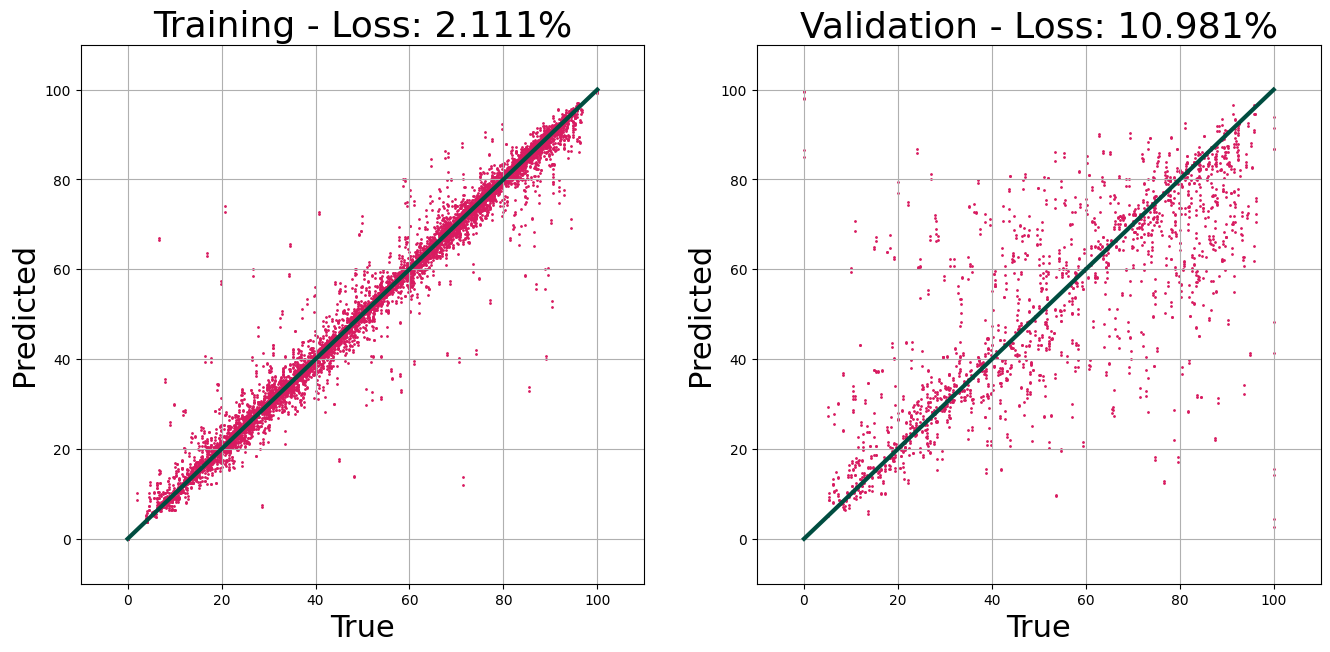

In [ ]:
mask = trues_train != 0.0
loss_train = np.mean(np.abs(preds_train - trues_train))

fig, ax = plt.subplots(1,2, figsize=(16,7))
ax[0].plot([0, 100], [0, 100], color="#004D40", linewidth=3)
ax[0].scatter(100 * trues_train, 100 * preds_train, color="#D81B60", s=1)
ax[0].set_xlim(-10,110)
ax[0].set_ylim(-10,110)
ax[0].set_xlabel("True", fontsize=22)
ax[0].set_ylabel("Predicted", fontsize=22)
ax[0].set_title(f"Training - Loss: {loss_train*100:.3f}%", fontsize=26)
ax[0].grid()

mask = trues_test != 0.0
loss_test = np.mean(np.abs(preds_test - trues_test))

ax[1].plot([0, 100], [0, 100], color="#004D40", linewidth=3)
ax[1].scatter(100 * trues_test, 100 * preds_test, color="#D81B60", s=1)
ax[1].set_xlim(-10,110)
ax[1].set_ylim(-10,110)
ax[1].set_xlabel("True", fontsize=22)
ax[1].set_ylabel("Predicted", fontsize=22)
ax[1].set_title(f"Validation - Loss: {loss_test*100:.3f}%", fontsize=26)
ax[1].grid()
plt.show()

# Optuna

In [10]:

def objective(trial):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # optimizer / training params
    batch_size = trial.suggest_int("batch_size", 16, 128, step=16)
    lr = trial.suggest_float("lr", 1e-5, 3e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)

    # architecture search space (fixed maximums; unused layer params are ignored)
    MAX_PRICE_LAYERS = 3
    MAX_TOKEN_LAYERS = 4
    MAX_HEAD_LAYERS = 4

    n_price_layers = trial.suggest_int("n_price_layers", 1, MAX_PRICE_LAYERS)
    n_token_layers = trial.suggest_int("n_token_layers", 1, MAX_TOKEN_LAYERS)
    n_head_layers = trial.suggest_int("n_head_layers", 1, MAX_HEAD_LAYERS)

    # per-layer size choices (names must be stable across trials)
    price_layer_choices = [8, 16, 32, 64]
    token_layer_choices = [64, 128, 256, 512, 1024]
    head_layer_choices = [128, 256, 512, 1024]

    price_sizes = [trial.suggest_categorical(f"price_size_{i}", price_layer_choices) for i in range(MAX_PRICE_LAYERS)]
    token_sizes = [trial.suggest_categorical(f"token_size_{i}", token_layer_choices) for i in range(MAX_TOKEN_LAYERS)]
    head_sizes = [trial.suggest_categorical(f"head_size_{i}", head_layer_choices) for i in range(MAX_HEAD_LAYERS)]

    # other head-wide param (optional)
    final_head_fc = trial.suggest_categorical("final_head_fc", [True, False])

    # build train (fit scaler) and validation (use train scaler) splits
    train_images, train_prices, train_tokens, train_ratings, scaler_train = make_split(train_idx, fit_scaler=True)
    val_images, val_prices, val_tokens, val_ratings, _ = make_split(val_idx, scaler=scaler_train, fit_scaler=False)

    # create datasets and loaders (mirrors are contained within each split)
    train_dataset = ImagePriceRatingDataset(train_ratings, train_images, train_prices, train_tokens)
    val_dataset = ImagePriceRatingDataset(val_ratings, val_images, val_prices, val_tokens)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # determine token dim from the created split
    token_dim = int(train_tokens.shape[1])

    # helper to build MLPs for variable depths
    def build_mlp(in_dim, sizes, n_layers, dropout):
        layers = []
        if n_layers <= 0:
            return nn.Identity()
        # first layer
        layers.append(nn.Linear(in_dim, sizes[0]))
        layers.append(nn.ReLU())
        for i in range(1, n_layers):
            layers.append(nn.Dropout(dropout))
            layers.append(nn.Linear(sizes[i - 1], sizes[i]))
            layers.append(nn.ReLU())
        return nn.Sequential(*layers)

    class ImagePriceModel(nn.Module):
        def __init__(self):
            super().__init__()
            weights = ResNet50_Weights.IMAGENET1K_V2
            image_branch = resnet50(weights=weights)
            self.image_branch = nn.Sequential(*list(image_branch.children())[:-1])  # [B,2048]

            self.price_branch = build_mlp(1, price_sizes, n_price_layers, dropout_rate)
            self.token_branch = build_mlp(token_dim, token_sizes, n_token_layers, dropout_rate)

            # determine price and token output dims (last layer size of each branch)
            price_out = price_sizes[n_price_layers - 1]
            token_out = token_sizes[n_token_layers - 1]
            joint_dim = 2048 + price_out + token_out

            # build head
            head_layers = []
            if n_head_layers == 1:
                head_layers.append(nn.Linear(joint_dim, 1))
            else:
                head_layers.append(nn.Linear(joint_dim, head_sizes[0]))
                head_layers.append(nn.ReLU())
                head_layers.append(nn.Dropout(dropout_rate))
                for i in range(1, n_head_layers):
                    prev = head_sizes[i - 1] if i - 1 < len(head_sizes) else head_sizes[-1]
                    curr = head_sizes[i] if i < len(head_sizes) else head_sizes[-1]
                    head_layers.append(nn.Linear(prev, curr))
                    if i != n_head_layers - 1:
                        head_layers.append(nn.ReLU())
                        head_layers.append(nn.Dropout(dropout_rate))
                # final mapping to 1 (ensure shape matches)
                head_layers.append(nn.Linear(head_sizes[n_head_layers - 1], 1))
            head_layers.append(nn.Sigmoid())
            self.head = nn.Sequential(*head_layers)

        def forward(self, image, price, token):
            img_feat = self.image_branch(image).flatten(1)
            price_feat = self.price_branch(price)
            token_feat = self.token_branch(token)
            x = torch.cat([img_feat, price_feat, token_feat], dim=1)
            return self.head(x)

    model = ImagePriceModel().to(device)
    criterion = nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_loss = float("inf")
    patience = 5
    bad_epochs = 0

    for epoch in range(20):
        model.train()
        for images_loaded, prices_loaded, tokens_loaded, ratings_loaded in train_loader:
            images_loaded = images_loaded.float().to(device)
            prices_loaded = prices_loaded.float().unsqueeze(1).to(device)
            tokens_loaded = tokens_loaded.float().to(device)
            ratings_loaded = ratings_loaded.float().unsqueeze(1).to(device)

            preds = model(images_loaded, prices_loaded, tokens_loaded)
            loss = criterion(preds, ratings_loaded)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images_loaded, prices_loaded, tokens_loaded, ratings_loaded in val_loader:
                images_loaded = images_loaded.float().to(device)
                prices_loaded = prices_loaded.float().unsqueeze(1).to(device)
                tokens_loaded = tokens_loaded.float().to(device)
                ratings_loaded = ratings_loaded.float().unsqueeze(1).to(device)

                preds = model(images_loaded, prices_loaded, tokens_loaded)
                loss = criterion(preds, ratings_loaded)
                val_loss += loss.item()

        val_loss /= max(1, len(val_loader))

        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            break

    return best_val_loss



sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(
    study_name="Ratings Identifier",
    direction="minimize",
    sampler=sampler,
)
study.optimize(objective, n_trials=200, show_progress_bar=True, n_jobs=1)

[I 2026-06-07 23:46:29,805] A new study created in memory with name: Ratings Identifier
Best trial: 0. Best value: 0.145796:   0%|          | 1/200 [05:55<19:38:04, 355.20s/it]

[I 2026-06-07 23:52:24,995] Trial 0 finished with value: 0.14579564587372104 and parameters: {'batch_size': 48, 'lr': 0.0022648248189516837, 'weight_decay': 0.0008471801418819979, 'dropout_rate': 0.2993292420985183, 'n_price_layers': 1, 'n_token_layers': 1, 'n_head_layers': 1, 'price_size_0': 8, 'price_size_1': 8, 'price_size_2': 32, 'token_size_0': 128, 'token_size_1': 128, 'token_size_2': 1024, 'token_size_3': 64, 'head_size_0': 512, 'head_size_1': 128, 'head_size_2': 1024, 'head_size_3': 256, 'final_head_fc': True}. Best is trial 0 with value: 0.14579564587372104.


Best trial: 1. Best value: 0.11727:   1%|          | 2/200 [10:36<17:09:23, 311.94s/it] 

[I 2026-06-07 23:57:06,657] Trial 1 finished with value: 0.11726991050556058 and parameters: {'batch_size': 32, 'lr': 1.2942956115511215e-05, 'weight_decay': 2.0013420622879995e-05, 'dropout_rate': 0.194338644844741, 'n_price_layers': 1, 'n_token_layers': 4, 'n_head_layers': 2, 'price_size_0': 64, 'price_size_1': 16, 'price_size_2': 16, 'token_size_0': 1024, 'token_size_1': 64, 'token_size_2': 256, 'token_size_3': 512, 'head_size_0': 128, 'head_size_1': 256, 'head_size_2': 128, 'head_size_3': 512, 'final_head_fc': True}. Best is trial 1 with value: 0.11726991050556058.


Best trial: 1. Best value: 0.11727:   2%|▏         | 3/200 [12:45<12:29:21, 228.23s/it]

...

[I 2026-06-08 03:12:59,914] Trial 197 pruned. 


Best trial: 159. Best value: 0.0966263: 100%|█████████▉| 199/200 [3:26:43<00:19, 19.15s/it]

[I 2026-06-08 03:13:13,234] Trial 198 pruned. 


Best trial: 159. Best value: 0.0966263: 100%|██████████| 200/200 [3:26:54<00:00, 62.07s/it]

[I 2026-06-08 03:13:24,717] Trial 199 pruned. 


In [13]:
import os
import pandas as pd

output_path = "JakobFugl/mirror_best_hyperparameters.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

best_row = {
    "study_name": study.study_name,
    "trial_number": study.best_trial.number,
    "best_value": study.best_value,
    **study.best_params,
}

pd.DataFrame([best_row]).to_csv(output_path, index=False)
print(f"Saved best hyperparameters to: {output_path}")

Saved best hyperparameters to: JakobFugl/mirror_best_hyperparameters.csv


In [ ]:


#best_params = study.best_params
best_df = pd.read_csv("hyper_parameters/mirror_best_hyperparameters.csv")
best_params = best_df.iloc[0].to_dict()

batch_size = best_params["batch_size"]
lr = best_params["lr"]
weight_decay = best_params["weight_decay"]
dropout_rate = best_params["dropout_rate"]

n_price_layers = best_params["n_price_layers"]
n_token_layers = best_params["n_token_layers"]
n_head_layers = best_params["n_head_layers"]

price_sizes = [best_params[f"price_size_{i}"] for i in range(3)]
token_sizes = [best_params[f"token_size_{i}"] for i in range(4)]
head_sizes = [best_params[f"head_size_{i}"] for i in range(4)]

train_images, train_prices, train_tokens, train_ratings, scaler_train = make_split(train_idx, fit_scaler=True)
val_images, val_prices, val_tokens, val_ratings, _ = make_split(val_idx, scaler=scaler_train, fit_scaler=False)

train_dataset = ImagePriceRatingDataset(train_ratings, train_images, train_prices, train_tokens)
val_dataset = ImagePriceRatingDataset(val_ratings, val_images, val_prices, val_tokens)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

token_dim = int(train_tokens.shape[1])
device = "cuda" if torch.cuda.is_available() else "cpu"

def build_mlp(in_dim, sizes, n_layers, dropout):
    layers = []
    layers.append(nn.Linear(in_dim, sizes[0]))
    layers.append(nn.ReLU())
    for i in range(1, n_layers):
        layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(sizes[i - 1], sizes[i]))
        layers.append(nn.ReLU())
    return nn.Sequential(*layers)

class FinalImagePriceModel(nn.Module):
    def __init__(self):
        super().__init__()
        weights = ResNet50_Weights.IMAGENET1K_V2
        image_branch = resnet50(weights=weights)
        self.image_branch = nn.Sequential(*list(image_branch.children())[:-1])

        self.price_branch = build_mlp(1, price_sizes, n_price_layers, dropout_rate)
        self.token_branch = build_mlp(token_dim, token_sizes, n_token_layers, dropout_rate)

        price_out = price_sizes[n_price_layers - 1]
        token_out = token_sizes[n_token_layers - 1]
        joint_dim = 2048 + price_out + token_out

        head_layers = []
        if n_head_layers == 1:
            head_layers.append(nn.Linear(joint_dim, 1))
        else:
            head_layers.append(nn.Linear(joint_dim, head_sizes[0]))
            head_layers.append(nn.ReLU())
            head_layers.append(nn.Dropout(dropout_rate))
            for i in range(1, n_head_layers):
                prev = head_sizes[i - 1] if i - 1 < len(head_sizes) else head_sizes[-1]
                curr = head_sizes[i] if i < len(head_sizes) else head_sizes[-1]
                head_layers.append(nn.Linear(prev, curr))
                if i != n_head_layers - 1:
                    head_layers.append(nn.ReLU())
                    head_layers.append(nn.Dropout(dropout_rate))
            head_layers.append(nn.Linear(head_sizes[n_head_layers - 1], 1))

        head_layers.append(nn.Sigmoid())
        self.head = nn.Sequential(*head_layers)

    def forward(self, image, price, token):
        img_feat = self.image_branch(image).flatten(1)
        price_feat = self.price_branch(price)
        token_feat = self.token_branch(token)
        x = torch.cat([img_feat, price_feat, token_feat], dim=1)
        return self.head(x)

model = FinalImagePriceModel().to(device)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

n_epochs = 10
for epoch in range(n_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = evaluate_loss(model, test_loader, criterion, device)
    print(f"epoch {epoch+1}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")


optimizer = torch.optim.Adam(model.parameters(), lr=lr/14, weight_decay=weight_decay)
n_epochs = 10
for epoch in range(n_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = evaluate_loss(model, test_loader, criterion, device)
    print(f"epoch {epoch+1}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

torch.save(model.state_dict(), "final_best_model_weights")
print("Saved final model to final_best_model_weights")

epoch 1: train_loss=0.1470 | val_loss=0.1256
epoch 2: train_loss=0.0859 | val_loss=0.1189
epoch 3: train_loss=0.0664 | val_loss=0.1140
epoch 4: train_loss=0.0556 | val_loss=0.1083
epoch 5: train_loss=0.0495 | val_loss=0.1084
epoch 6: train_loss=0.0446 | val_loss=0.1090
epoch 7: train_loss=0.0424 | val_loss=0.1054
epoch 8: train_loss=0.0401 | val_loss=0.1055
epoch 9: train_loss=0.0374 | val_loss=0.1027
epoch 10: train_loss=0.0363 | val_loss=0.1059
epoch 11: train_loss=0.0345 | val_loss=0.1038
epoch 12: train_loss=0.0331 | val_loss=0.1030
epoch 13: train_loss=0.0323 | val_loss=0.1049
epoch 14: train_loss=0.0325 | val_loss=0.1023
epoch 15: train_loss=0.0312 | val_loss=0.1008
epoch 16: train_loss=0.0304 | val_loss=0.1023
epoch 17: train_loss=0.0305 | val_loss=0.1014
epoch 18: train_loss=0.0308 | val_loss=0.0998
epoch 19: train_loss=0.0300 | val_loss=0.1005
epoch 20: train_loss=0.0290 | val_loss=0.1021
epoch 1: train_loss=0.0263 | val_loss=0.0992
epoch 2: train_loss=0.0234 | val_loss=0.0979